#Ridge Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

In [ ]:
boston_dataset = pd.read_csv('boston.csv')
boston_dataset.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
X= boston_dataset.drop('medv',axis=1)
y = boston_dataset.medv

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state=242 )


In [ ]:
lreg = LinearRegression()
lreg.fit(x_train, y_train)
lreg_y_pred = lreg.predict(x_test)
mean_squared_error = np.mean((lreg_y_pred - y_test)**2)
print("Mean squared Error on test set : ", mean_squared_error)
print('R2 score on test set : ', r2_score(y_test, lreg_y_pred))

lreg_coefficient = pd.DataFrame()
lreg_coefficient["Columns"] = x_train.columns
lreg_coefficient['Coefficient Estimate'] = pd.Series(lreg.coef_)
lreg_coefficient

Mean squared Error on test set :  20.174896939801712
R2 score on test set :  0.6854297655941504


,Columns,Coefficient Estimate
0,crim,-0.113309
1,zn,0.044165
2,indus,0.052747
3,chas,2.602397
4,nox,-17.566229
5,rm,3.948693
6,age,-0.006750
7,dis,-1.562715
8,rad,0.321866
9,tax,-0.013736


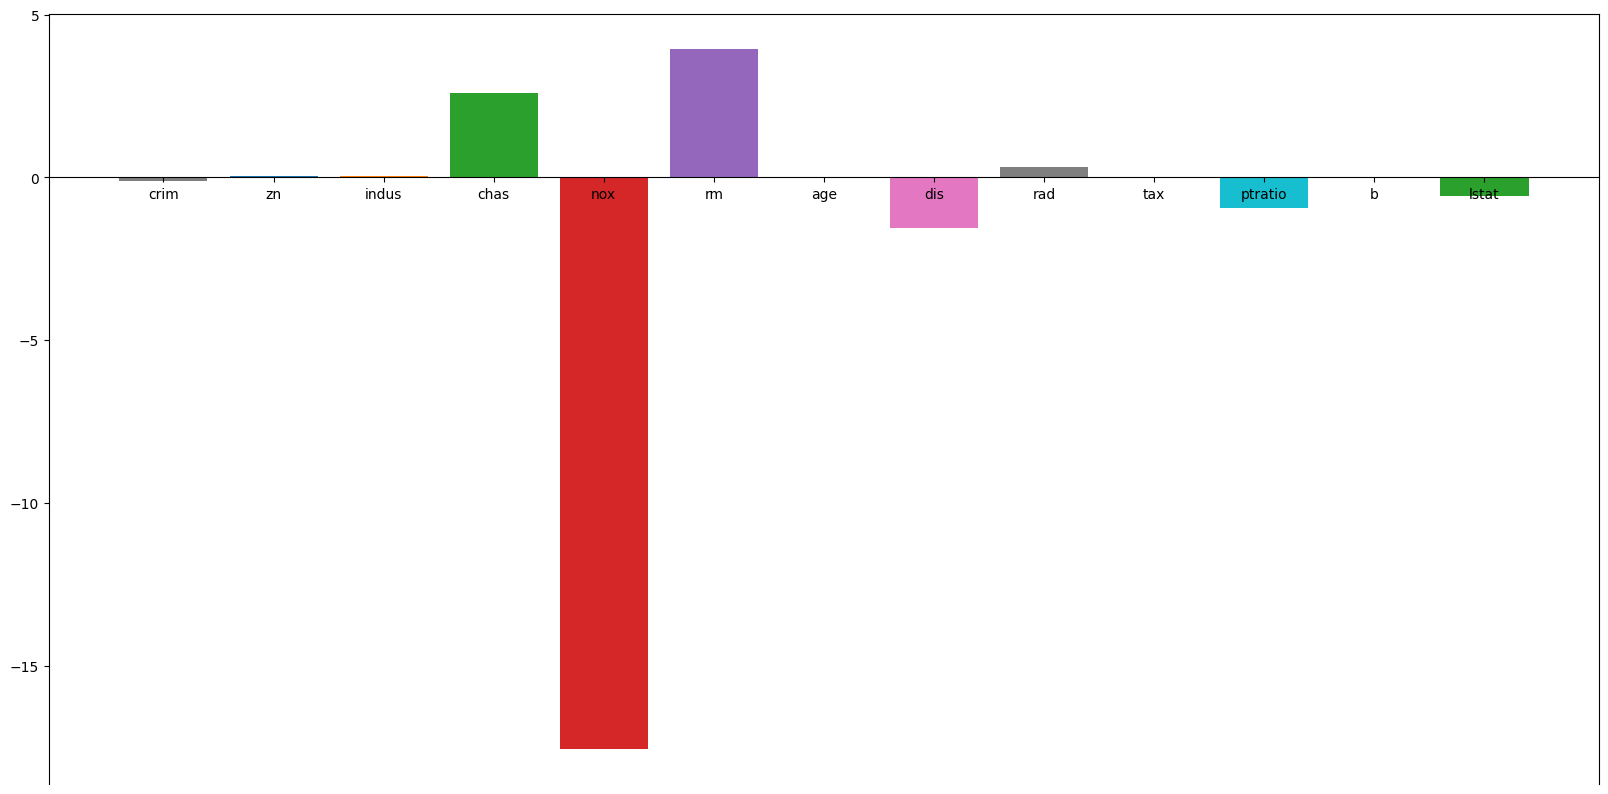

In [ ]:
fig, ax = plt.subplots(figsize =(20, 10))
color =['tab:gray', 'tab:blue', 'tab:orange',
'tab:green', 'tab:red', 'tab:purple', 'tab:brown',
'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
'tab:orange', 'tab:green', 'tab:blue', 'tab:olive']

ax.bar(lreg_coefficient["Columns"],lreg_coefficient['Coefficient Estimate'], color = color)
ax.spines['bottom'].set_position('zero')
plt.style.use('ggplot')
plt.show()

In [ ]:
# import ridge regression from sklearn library
from sklearn.linear_model import Ridge

# Train the model
ridgeR = Ridge(alpha =1)
ridgeR.fit(x_train, y_train)
y_pred = ridgeR.predict(x_test)

# calculate mean square error
mean_squared_error_ridge = np.mean((y_pred - y_test)**2)
print('mean squared error on test set: ', mean_squared_error_ridge)
print('R2 score on test set : ', r2_score(y_test, y_pred))

# get ridge coefficient and print them
lreg_coefficient['Coefficient Estimate_Ridge_1'] = pd.Series(ridgeR.coef_)
lreg_coefficient

mean squared error on test set:  20.555484263429637
R2 score on test set :  0.6794955868985784


,Columns,Coefficient Estimate,Coefficient Estimate_Ridge_1
0,crim,-0.113309,-0.110777
1,zn,0.044165,0.046846
2,indus,0.052747,0.020380
3,chas,2.602397,2.547260
4,nox,-17.566229,-8.871777
5,rm,3.948693,3.965163
6,age,-0.006750,-0.012808
7,dis,-1.562715,-1.426393
8,rad,0.321866,0.300464
9,tax,-0.013736,-0.014360


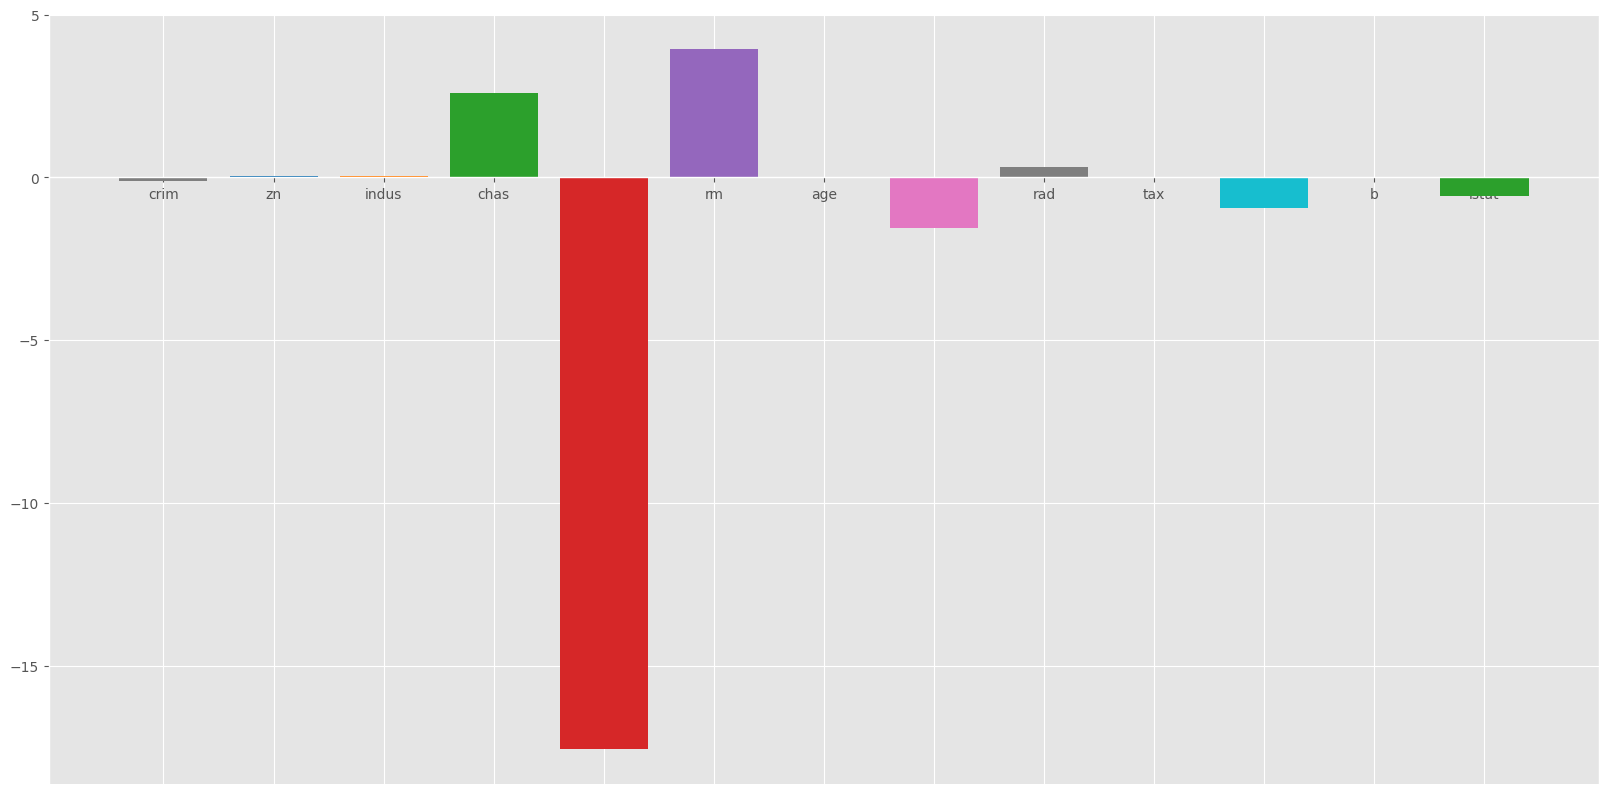

In [ ]:
fig, ax = plt.subplots(figsize =(20, 10))
color =['tab:gray', 'tab:blue', 'tab:orange',
'tab:green', 'tab:red', 'tab:purple', 'tab:brown',
'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
'tab:orange', 'tab:green', 'tab:blue', 'tab:olive']

ax.bar(lreg_coefficient["Columns"],lreg_coefficient['Coefficient Estimate'], color = color)
ax.spines['bottom'].set_position('zero')
plt.style.use('ggplot')
plt.show()

In [ ]:
from sklearn.linear_model import Ridge

# Train the model
ridgeR = Ridge(alpha =10)
ridgeR.fit(x_train, y_train)
y_pred = ridgeR.predict(x_test)

# calculate mean square error
mean_squared_error_ridge = np.mean((y_pred - y_test)**2)
print('mean_squared_erroron test set : ', mean_squared_error_ridge)
print('R2 score on test set : ', r2_score(y_test, y_pred))

# get ridge coefficient and print them
lreg_coefficient['Coefficient Estimate_Ridge_2'] = pd.Series(ridgeR.coef_)
lreg_coefficient

mean_squared_erroron test set :  21.34630674788196
R2 score on test set :  0.6671649556666139


,Columns,Coefficient Estimate,Coefficient Estimate_Ridge_1,Coefficient Estimate_Ridge_2
0,crim,-0.113309,-0.110777,-0.109531
1,zn,0.044165,0.046846,0.050371
2,indus,0.052747,0.020380,-0.003929
3,chas,2.602397,2.547260,1.913803
4,nox,-17.566229,-8.871777,-1.629101
5,rm,3.948693,3.965163,3.698393
6,age,-0.006750,-0.012808,-0.014973
7,dis,-1.562715,-1.426393,-1.310521
8,rad,0.321866,0.300464,0.295494
9,tax,-0.013736,-0.014360,-0.015521


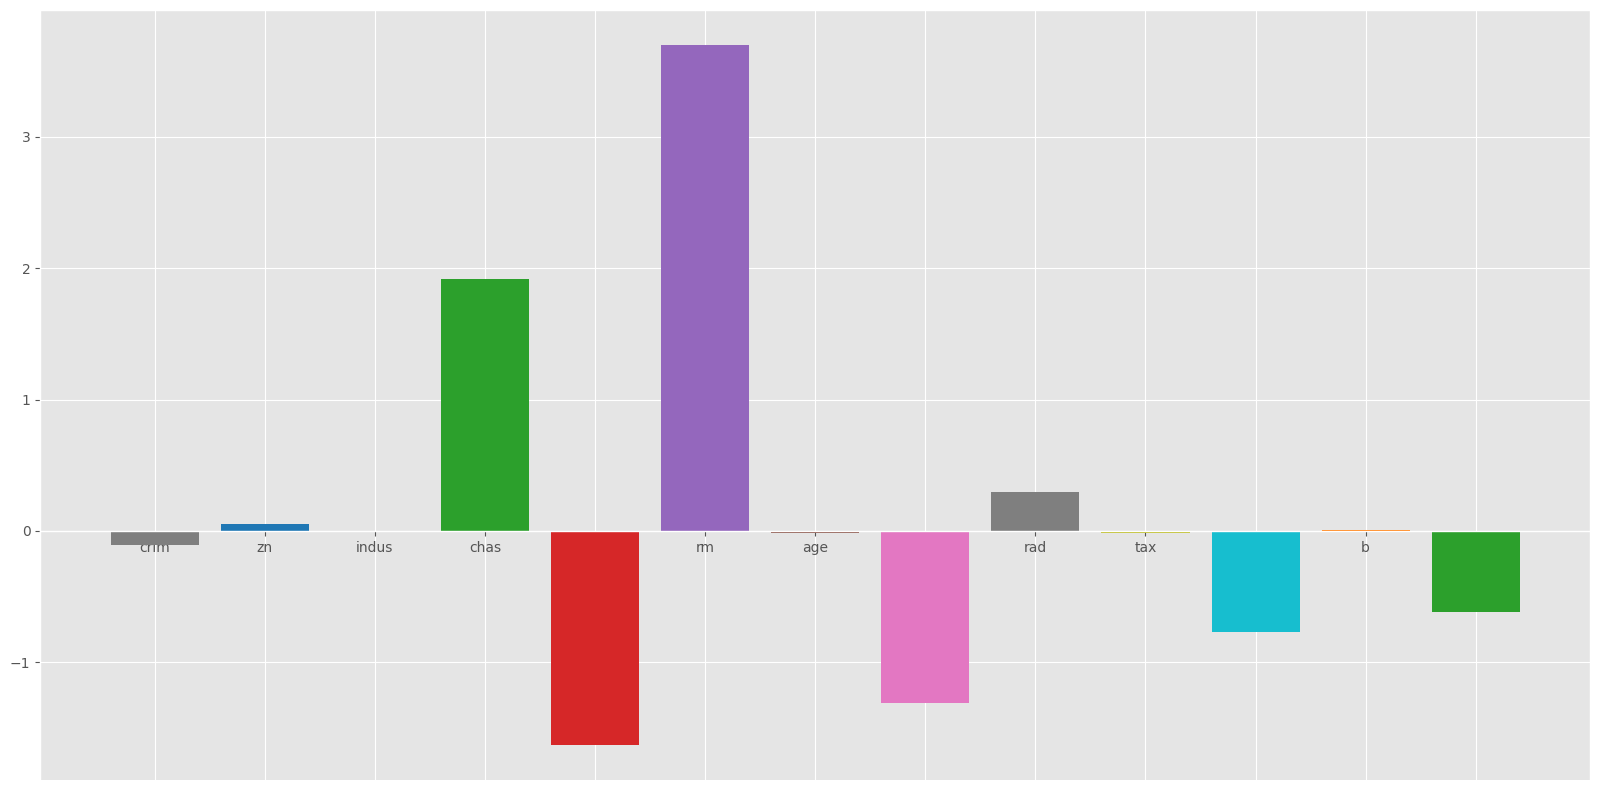

In [ ]:
# plotting the coefficient score
fig, ax = plt.subplots(figsize =(20, 10))

color =['tab:gray', 'tab:blue', 'tab:orange',
'tab:green', 'tab:red', 'tab:purple', 'tab:brown',
'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
'tab:orange', 'tab:green', 'tab:blue', 'tab:olive']

ax.bar(lreg_coefficient["Columns"], lreg_coefficient['Coefficient Estimate_Ridge_2'], color = color)
ax.spines['bottom'].set_position('zero')
plt.style.use('ggplot')
plt.show()

In [ ]:
model = Ridge()
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

In [ ]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_estimator_

Ridge(alpha=0.0001)

In [ ]:
y_pred = ridgeR.predict(x_test)
mean_squared_error_ridge = np.mean((y_pred - y_test)**2)
print('mean_squared_erroron test set : ', mean_squared_error_ridge)
print('R2 score on test set : ', r2_score(y_test, y_pred))

mean_squared_erroron test set :  21.34630674788196
R2 score on test set :  0.6671649556666139


#Lasso Regression

In [ ]:
lassoR = Lasso(alpha = 0.001)
lassoR.fit(x_train, y_train)
y_pred = lassoR.predict(x_test)
mean_squared_error_lasso = np.mean((y_pred - y_test)**2)
print('mean_squared_erroron test set : ', mean_squared_error_lasso)
print('R2 score on test set : ', r2_score(y_pred, y_test))

mean_squared_erroron test set :  20.17669167282807
R2 score on test set :  0.6571696429790304
